# Notebook Overview

This notebook analyzes Optuna studies produced by `SignalTrafficOptimization.py`.

- Goal: inspect the hyperparameter search history and identify architectures that generalize better across demand levels
- Typical inputs: Optuna SQLite databases and saved trial artifacts
- Recommended focus: best trials, sensitivity to architecture choices, and evaluation across traffic volumes


## Hyperparameter Search Description

The hyperparameter optimization was conducted using **Optuna** with a Tree-Structured Parzen Estimator (TPE) sampler.  
The goal was to tune both algorithmic and architectural aspects of a **PPO-based reinforcement learning agent** for traffic signal control.  
All trials were tracked in **Weights & Biases (W&B)** for reproducibility and post-analysis.

---

### PPO Hyperparameters

- **gamma**: Discount factor applied to future rewards.  
  Higher values make the agent more farsighted, encouraging it to optimize long-term traffic flow, whereas lower values prioritize immediate improvements.  
  *Range:* 0.98 – 0.997

- **lambd**: GAE (Generalized Advantage Estimation) parameter balancing bias and variance.  
  Smaller values increase bias (faster updates), while larger values improve stability but require more samples.  
  *Range:* 0.92 – 0.98

- **clip_range**: Clipping threshold for the PPO surrogate loss.  
  Prevents large, unstable updates to the policy during optimization.  
  *Range:* 0.12 – 0.25

- **entropy_coef**: Weight of the entropy term encouraging policy exploration.  
  Higher values lead to more exploratory behavior, while lower values push toward exploitation.  
  *Range:* 1e-3 – 2e-2 (log scale)

- **K_epochs**: Number of policy update epochs per collected batch of experiences.  
  *Range:* 5 – 15

- **learning_rate**: Optimizer learning rate controlling gradient step size.  
  *Range:* 1e-5 – 1e-3 (log scale)

- **optimizer**: Optimization algorithm used for training.  
  *Options:* Adam, AdamW

- **weight_decay**: L2 penalty term for AdamW optimizer, improving regularization and stability.  
  *Range:* 1e-6 – 1e-4 (log scale)

- **L2-reg**: Additional L2 regularization parameter applied to network weights.  
  *Range:* 1e-12 – 1e-3 (log scale)

---

### Agent Network Hyperparameters

The agent’s architecture combines convolutional, recurrent, and fully-connected layers to process spatio-temporal information from the traffic environment.

- **num_conv_layers**: Number of convolutional layers used to extract spatial features from the input.  
  *Range:* 1 – 2

- **num_filter_i**: Number of convolutional filters per layer.  
  *Options:* {16, 32, 64, 128, 256}

- **stride_size_i**: Stride size used in each convolutional layer, controlling spatial downsampling.  
  *Range:* 1 – 3

- **kernel_size_i**: Convolution kernel size determining the receptive field.  
  *Range:* 3 – 9 (step = 2)

- **lstm_units**: Number of hidden units in the LSTM layer, responsible for capturing temporal dependencies.  
  *Options:* {16, 32, 64, 96, 128, 256}

- **num_mlp_layers**: Number of fully-connected layers following the LSTM.  
  *Range:* 2 – 3

- **mlp_neurons_i**: Number of neurons in each hidden MLP layer.  
  *Options:* {32, 64, 128}

---

### Environment and Run Configuration

- **State dimension:** [3, 48, 46]  
- **Action dimension:** 8 (number of possible signal phases)  
- **Max episode steps:** 3600  
- **Green and yellow durations:** 6s and 7s respectively  
- **Total episodes:** 800  
- **Evaluation demand:** [1000, 1100, …, 2100] vehicles/hour  
- **Batch size:** 16  
- **T_horizon:** 256  
- **Advantage normalization:** Enabled  
- **Traffic distribution:** Weibull  

---

### Reward Function

The reward used during training was defined as:

\[
R = (Q_{t-1} - Q_t) - 0.2 \*Q_t
\]

where:
- \( Q_t \) represents the current total queue length, and  
- \( Q_{t-1} \) represents the queue length from the previous step.

An **increase in reward** corresponds to a **reduction in queue length**, indicating improved traffic flow and reduced congestion.  
Conversely, a **decrease in reward** occurs when queues grow, penalizing inefficient signal actions or poor phase timing.  
The coefficient \( 0.2 \) balances the direct queue reduction term and the penalty for maintaining long queues.


In [1]:
import optuna, pandas as pd
study = optuna.load_study(study_name="RL-ppo-search", storage="sqlite:///RL_signal.db")
df = study.trials_dataframe(attrs=("number", "value", "state", "params",
                                   "datetime_start", "datetime_complete", "duration"),
                            multi_index=False)
# Keep only completed trials
dfc = df[df["state"]=="COMPLETE"].copy()

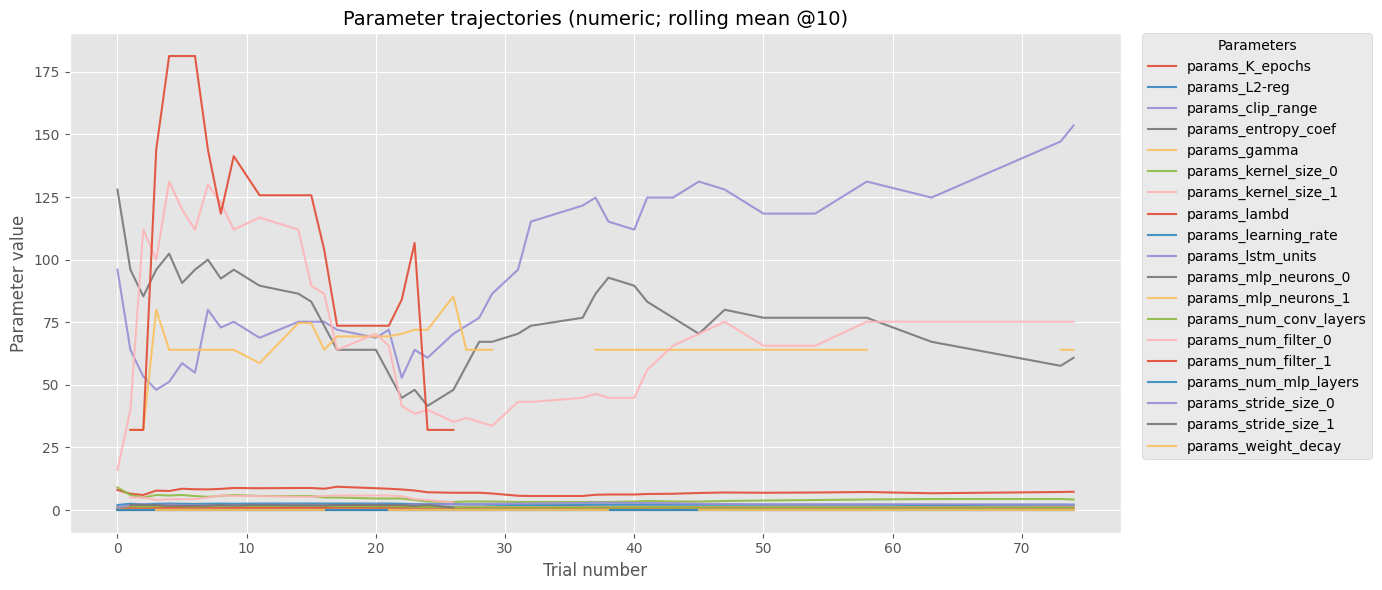

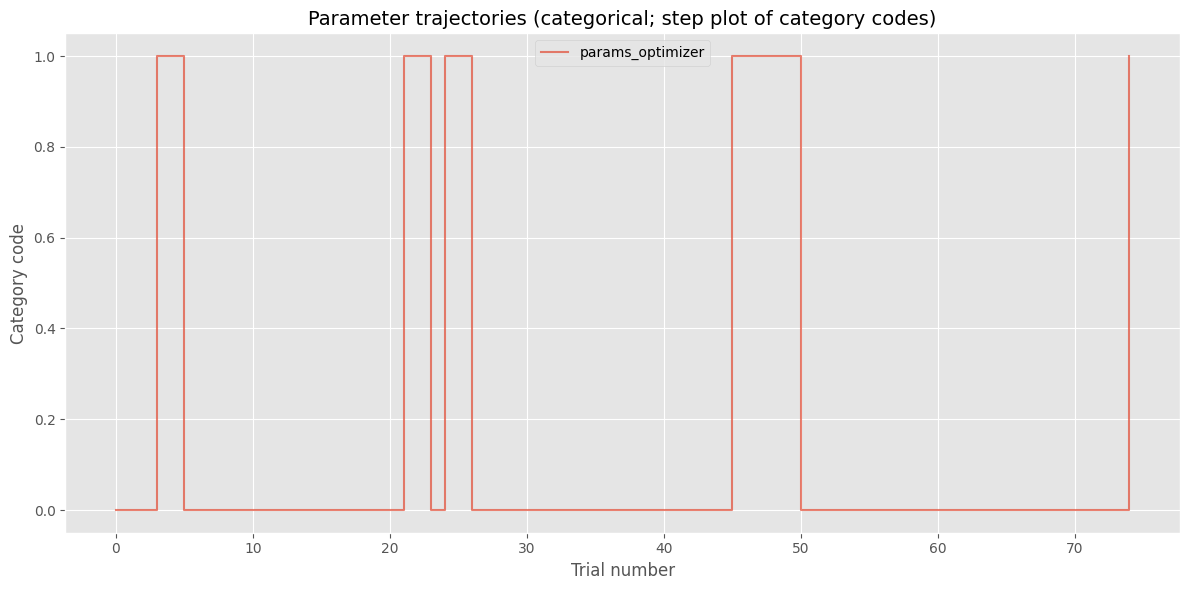


Categorical code maps:
params_optimizer: 0->adam, 1->adamw


In [6]:
from pandas.api.types import is_numeric_dtype
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

# 2) Identify param columns
pcols = [c for c in dfc.columns if c.startswith("params_")]

# 3) Split numeric vs categorical
num_cols = [c for c in pcols if is_numeric_dtype(dfc[c]) or pd.to_numeric(dfc[c], errors='coerce').notna().all()]
cat_cols = [c for c in pcols if c not in num_cols]

if num_cols:
    plt.figure(figsize=(12, 6))
    df_num = dfc.set_index("number")[num_cols].apply(pd.to_numeric, errors="coerce")
    ax = df_num.rolling(10, min_periods=1).mean().plot(alpha=0.9, ax=plt.gca())

    ax.set_title("Parameter trajectories (numeric; rolling mean @10)", fontsize=14)
    ax.set_xlabel("Trial number", fontsize=12)
    ax.set_ylabel("Parameter value", fontsize=12)

    # Move legend outside the plot area
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])  # shrink width to make space
    ax.legend(title="Parameters", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=10)

    plt.tight_layout()
    plt.show()


# --- Categorical parameter trajectories ---
if cat_cols:
    plt.figure(figsize=(12, 6))  # ⬅️ Bigger figure
    maps = {}
    for c in cat_cols:
        codes, uniques = pd.factorize(dfc[c], sort=True)
        maps[c] = dict(enumerate(uniques))
        s = pd.Series(codes, index=dfc["number"]).replace(-1, np.nan)
        s.plot(drawstyle="steps-post", alpha=0.7, label=c)

    plt.title("Parameter trajectories (categorical; step plot of category codes)", fontsize=14)
    plt.xlabel("Trial number", fontsize=12)
    plt.ylabel("Category code", fontsize=12)
    plt.legend(fontsize=10, loc="best")
    plt.tight_layout()
    plt.show()

    print("\nCategorical code maps:")
    for c, mp in maps.items():
        print(f"{c}: " + ", ".join([f"{k}->{v}" for k, v in mp.items()]))

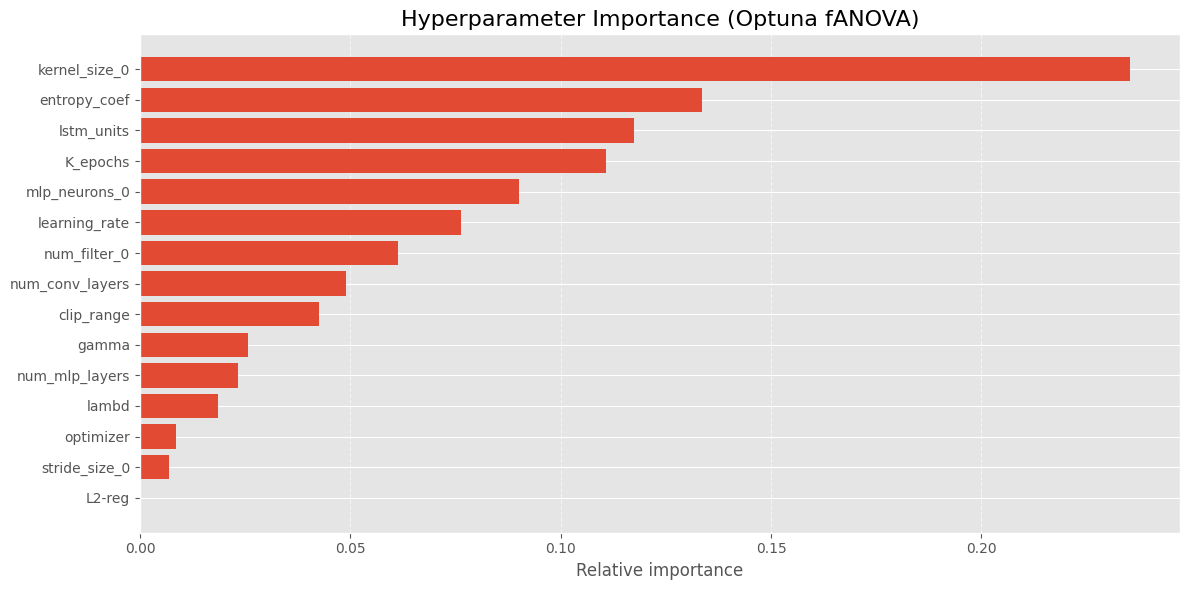

In [7]:
import matplotlib.pyplot as plt
from optuna.importance import get_param_importances

imps = get_param_importances(study)
labels = list(imps.keys())
values = list(imps.values())

plt.figure(figsize=(12, max(6, 0.4*len(labels))))  # adaptive height
bars = plt.barh(labels, values)
plt.gca().invert_yaxis()  # most important at top

plt.title("Hyperparameter Importance (Optuna fANOVA)", fontsize=16)
plt.xlabel("Relative importance", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

C:\Users\jazg2\AppData\Local\Temp\ipykernel_24616\3436580397.py:3: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study);


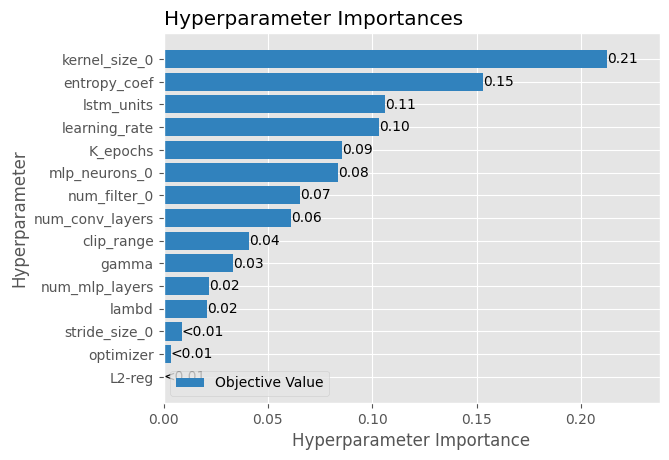

In [8]:
from optuna.visualization.matplotlib import (plot_param_importances, plot_slice,
                                             plot_parallel_coordinate, plot_contour)
plot_param_importances(study);

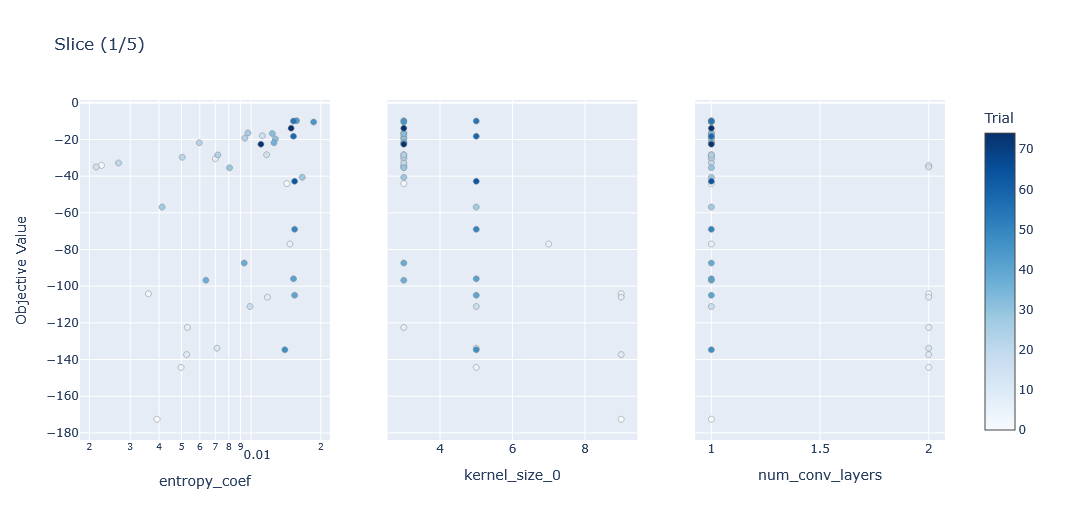

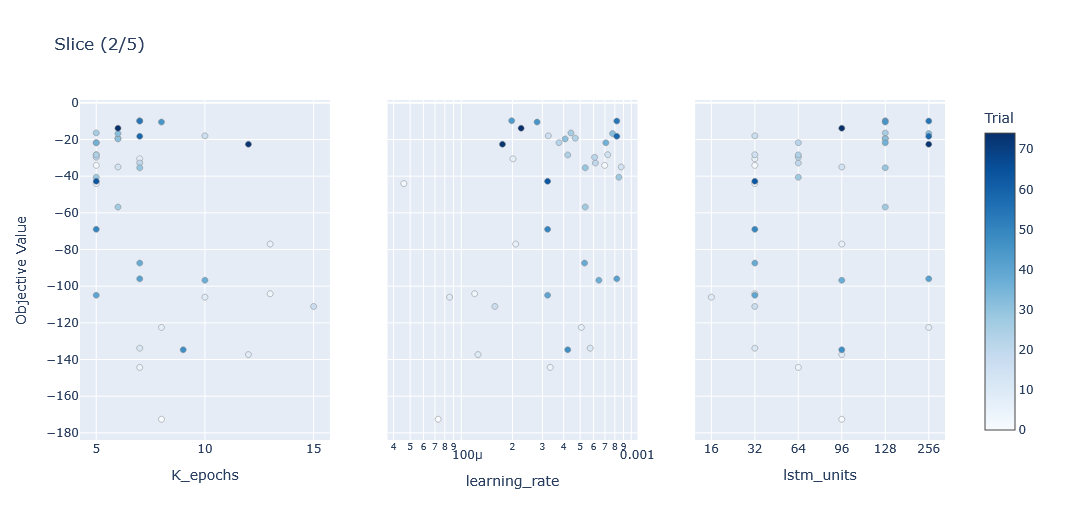

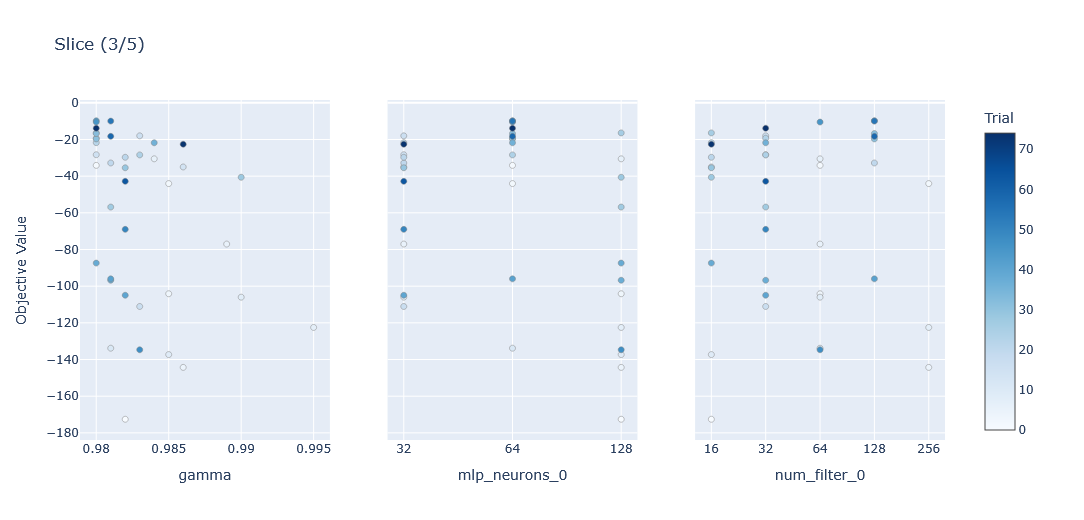

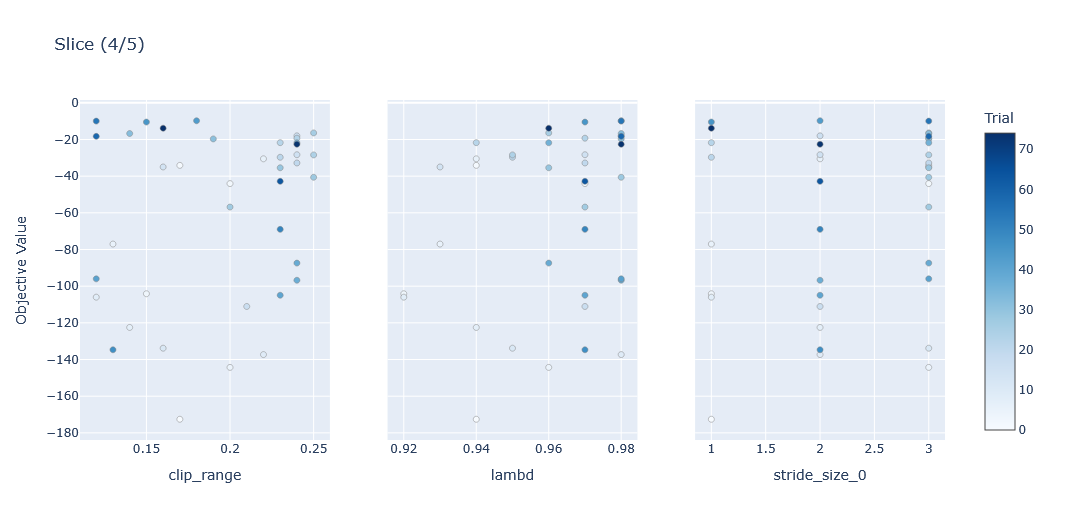

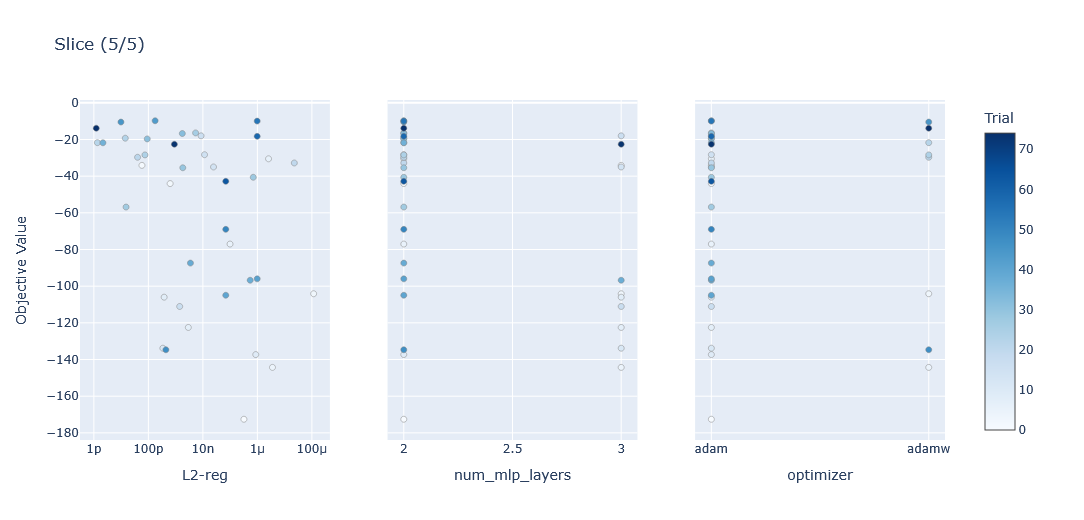

In [14]:
import math
import optuna
from optuna.visualization import plot_slice

params = list(dict(sorted(imps.items(), key=lambda kv: kv[1], reverse=True)).keys())
def slice_in_chunks(study, params, n_groups=4, width_per_param=320, height=500):
    """Return a list of Plotly figs; each fig shows a chunk of params."""
    figs = []
    chunk = math.ceil(len(params)/n_groups)
    for i in range(0, len(params), chunk):
        grp = params[i:i+chunk]
        fig = plot_slice(study, params=grp)
        fig.update_layout(
            width=max(900, width_per_param*len(grp)),
            height=height,
            title=f"Slice ({i//chunk + 1}/{math.ceil(len(params)/chunk)})"
        )
        figs.append(fig)
    return figs

figs = slice_in_chunks(study, params, n_groups=5, width_per_param=340, height=520)
for fig in figs:
    fig.show()


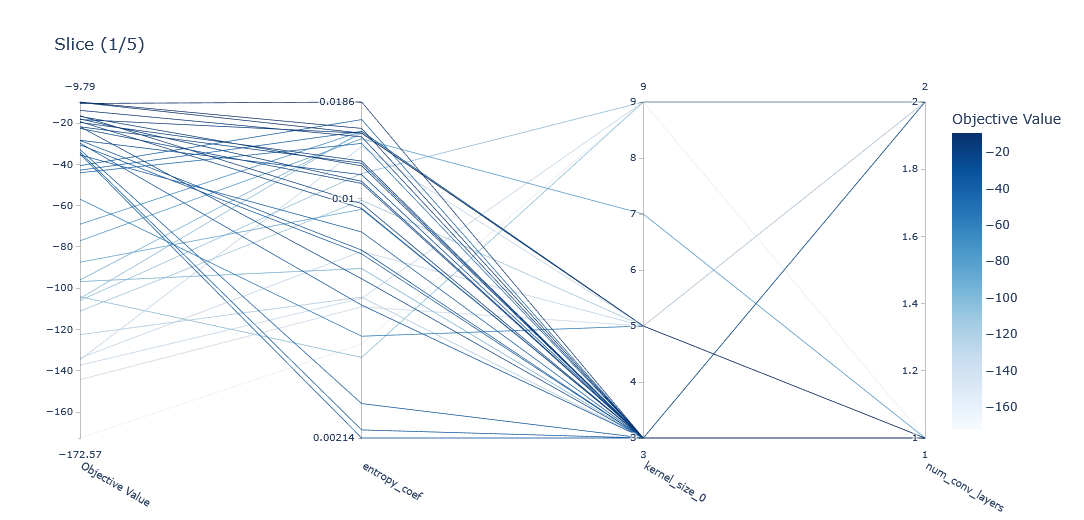

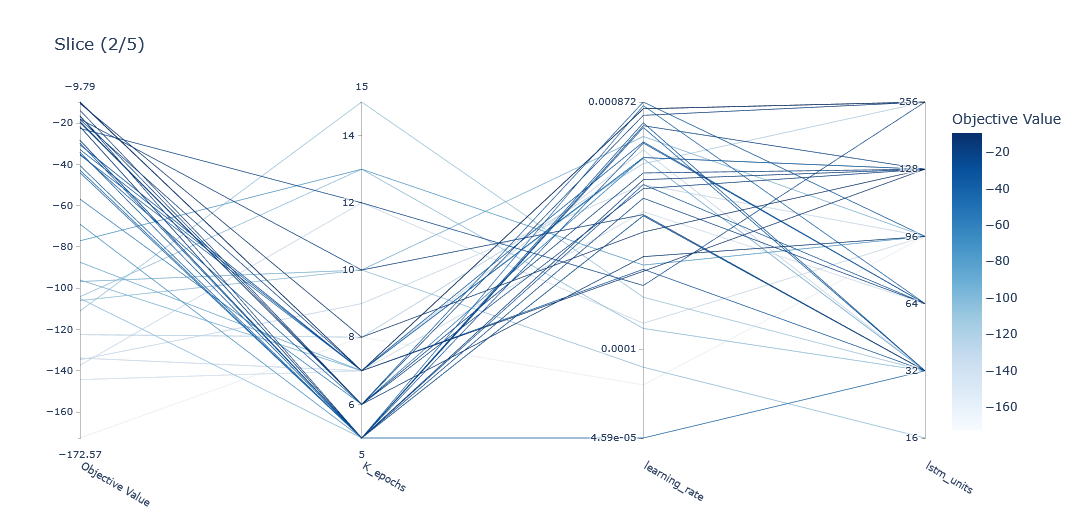

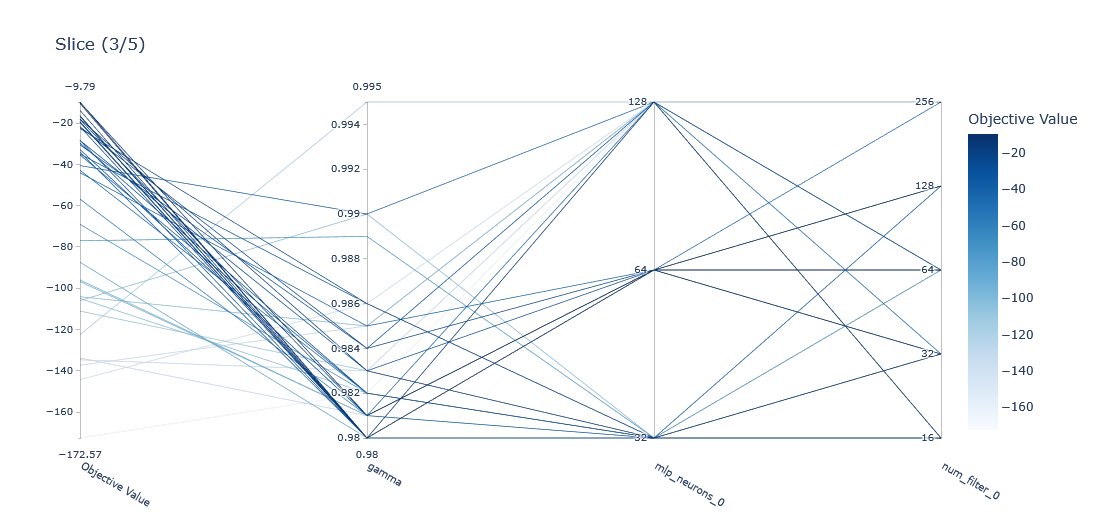

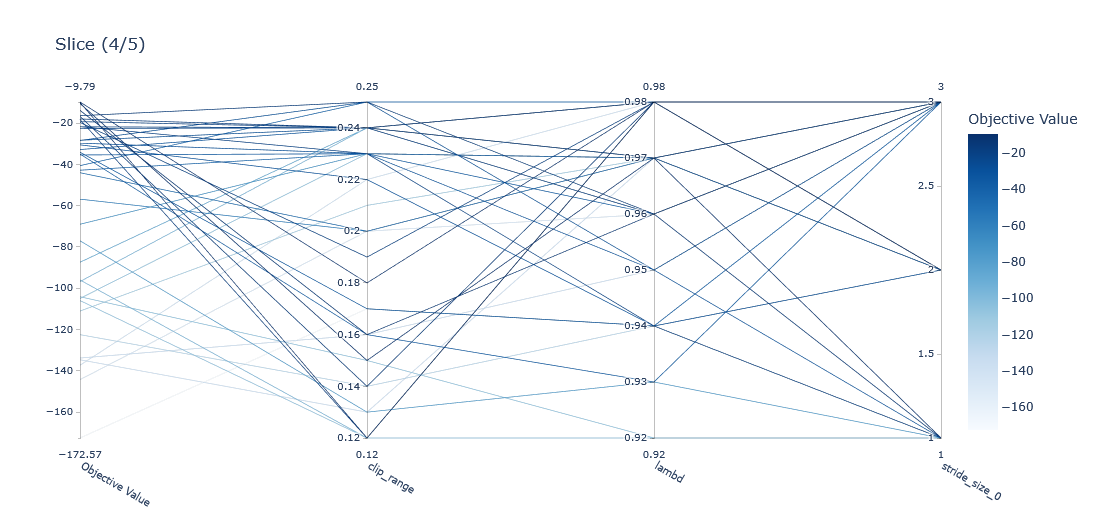

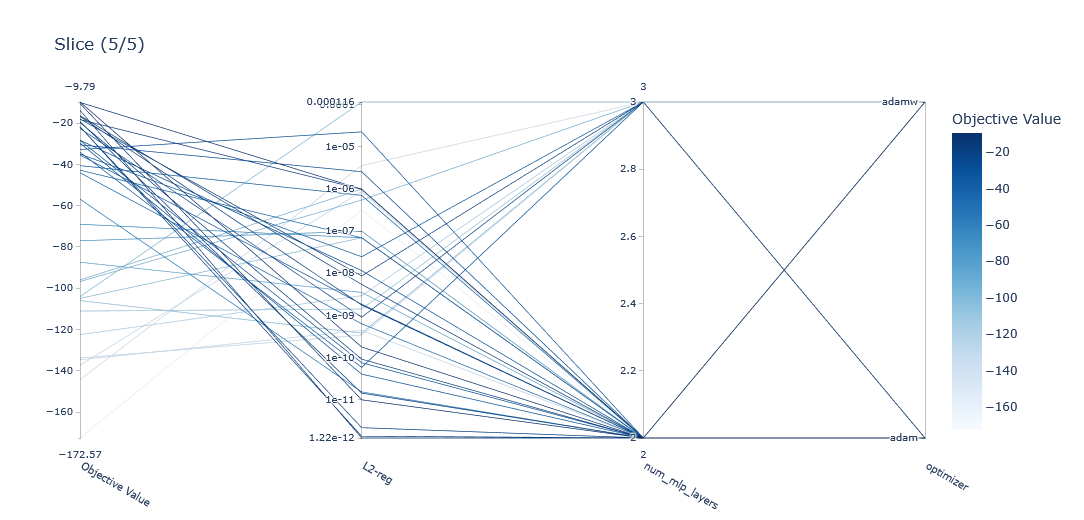

In [15]:
from optuna.visualization import plot_parallel_coordinate

def parallel_in_chunks(study, params, n_groups=4, width_per_param=320, height=500):
    """Return a list of Plotly figs; each fig shows a chunk of params."""
    figs = []
    chunk = math.ceil(len(params)/n_groups)
    for i in range(0, len(params), chunk):
        grp = params[i:i+chunk]
        fig = plot_parallel_coordinate(study, params=grp)
        fig.update_layout(
            width=max(900, width_per_param*len(grp)),
            height=height,
            title=f"Slice ({i//chunk + 1}/{math.ceil(len(params)/chunk)})"
        )
        figs.append(fig)
    return figs

figs = parallel_in_chunks(study, params, n_groups=5, width_per_param=340, height=520)
for fig in figs:
    fig.show()

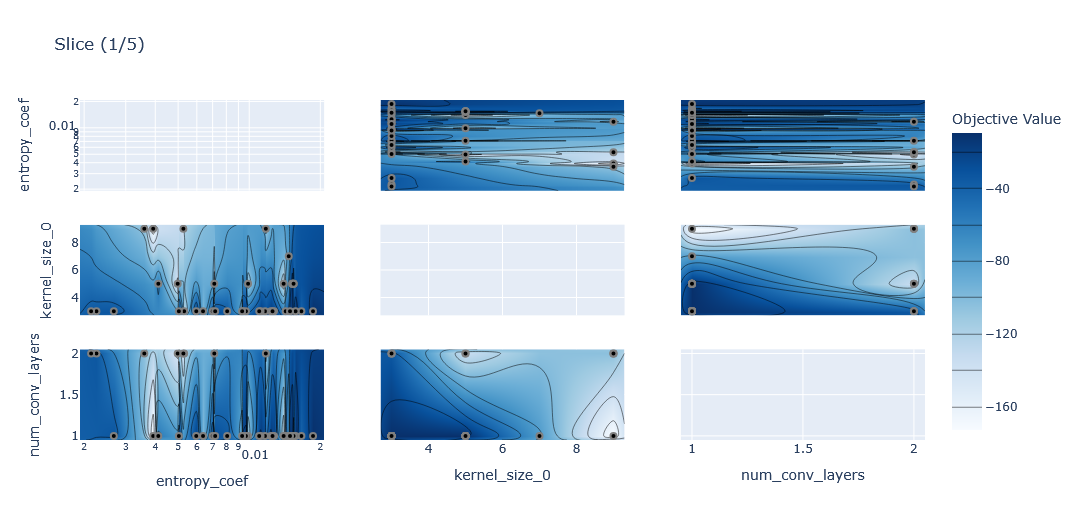

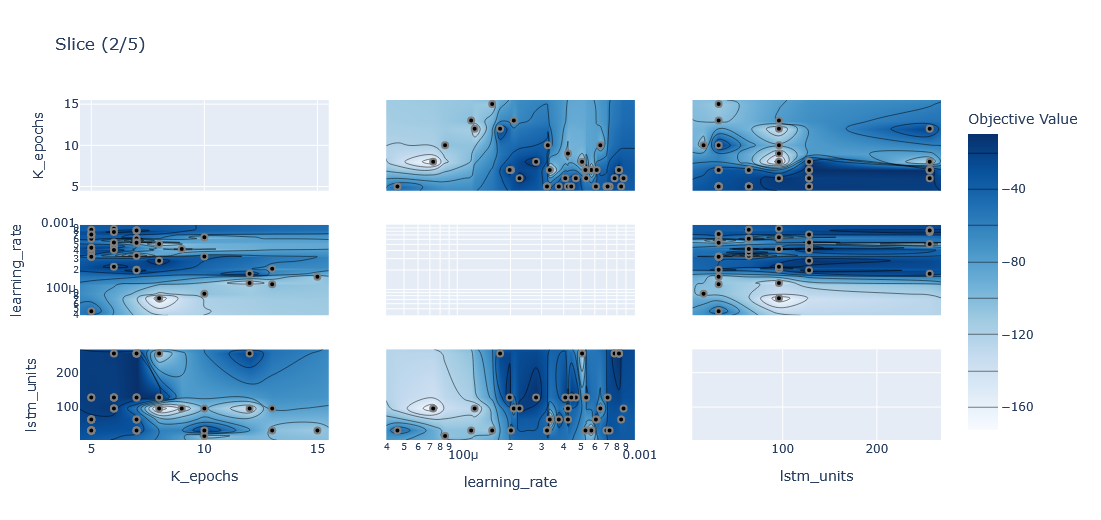

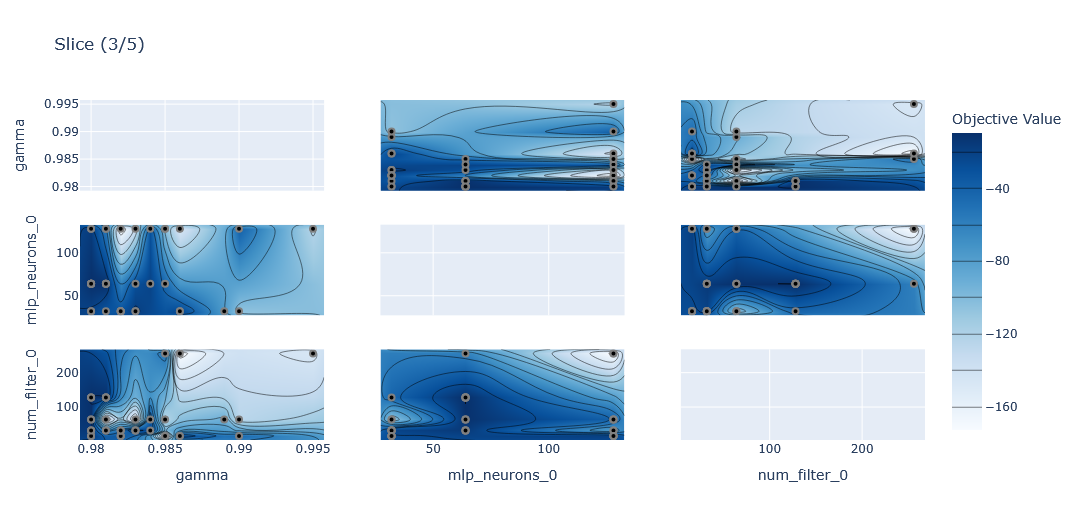

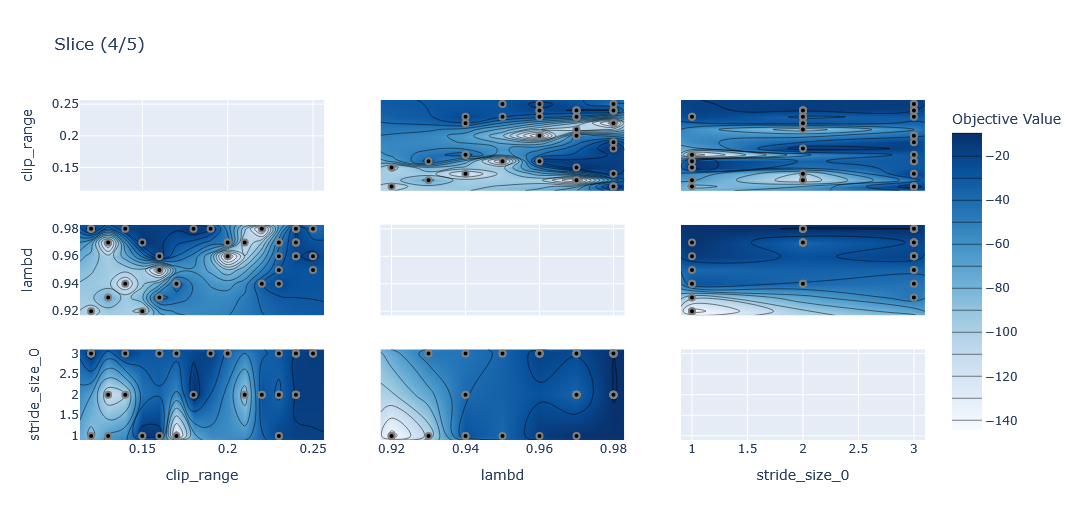

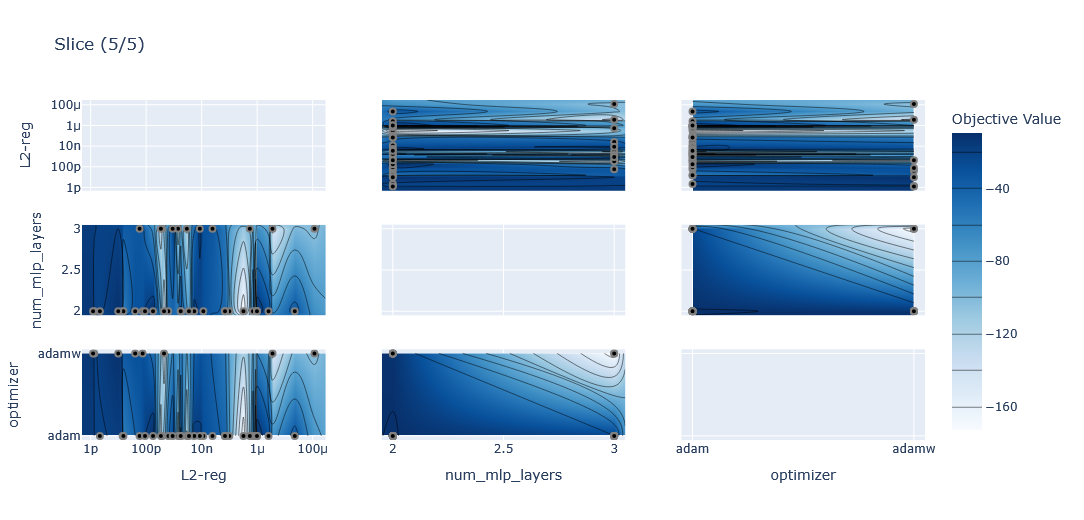

In [16]:
from optuna.visualization import plot_contour

def contour_in_chunks(study, params, n_groups=4, width_per_param=320, height=500):
    """Return a list of Plotly figs; each fig shows a chunk of params."""
    figs = []
    chunk = math.ceil(len(params)/n_groups)
    for i in range(0, len(params), chunk):
        grp = params[i:i+chunk]
        fig = plot_contour(study, params=grp)
        fig.update_layout(
            width=max(900, width_per_param*len(grp)),
            height=height,
            title=f"Slice ({i//chunk + 1}/{math.ceil(len(params)/chunk)})"
        )
        figs.append(fig)
    return figs

figs = contour_in_chunks(study, params, n_groups=5, width_per_param=340, height=520)
for fig in figs:
    fig.show()

In [31]:
# Summaries of visited regions
visited = dfc[num_cols].filter(like="params_")
summary = visited.agg(["min","median","max","nunique"]).T
print(summary.sort_index())
for c in cat_cols:
    if dfc[c].dtype == "object":
        print(c, dfc[c].value_counts().head(10))

                                 min        median         max  nunique
params_K_epochs         5.000000e+00  7.000000e+00   15.000000      9.0
params_L2-reg           1.221667e-12  3.209537e-09    0.000116     36.0
params_clip_range       1.200000e-01  2.050000e-01    0.250000     14.0
params_entropy_coef     2.140038e-03  1.045458e-02    0.018624     36.0
params_gamma            9.800000e-01  9.820000e-01    0.995000     10.0
params_kernel_size_0    3.000000e+00  3.000000e+00    9.000000      4.0
params_kernel_size_1    3.000000e+00  5.000000e+00    9.000000      4.0
params_lambd            9.200000e-01  9.700000e-01    0.980000      7.0
params_learning_rate    4.589824e-05  4.228403e-04    0.000872     36.0
params_lstm_units       1.600000e+01  9.600000e+01  256.000000      6.0
params_mlp_neurons_0    3.200000e+01  6.400000e+01  128.000000      3.0
params_mlp_neurons_1    3.200000e+01  6.400000e+01  128.000000      3.0
params_num_conv_layers  1.000000e+00  1.000000e+00    2.000000  

In [26]:
import optuna.visualization.matplotlib as ov
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (16, 10)

completed = tuple([optuna.trial.TrialState.COMPLETE,
                   optuna.trial.TrialState.PRUNED,
                   optuna.trial.TrialState.FAIL])

sub_study = optuna.study.create_study(directions=study.directions)  # temp in-memory
# re-add only real trials to a temp study object for clean plots
for t in study.get_trials(deepcopy=False, states=completed):
    sub_study.add_trial(t)

[I 2025-10-20 00:51:18,330] A new study created in memory with name: no-name-ed731ed1-f48b-457d-b3f2-6e12db5afb53


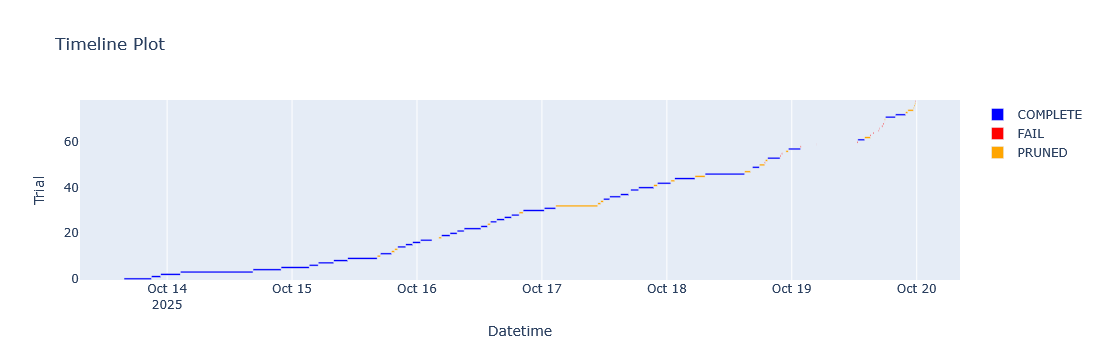

In [28]:
fig = optuna.visualization.plot_timeline(sub_study)
fig.show()

C:\Users\jazg2\AppData\Local\Temp\ipykernel_24616\3938398245.py:1: ExperimentalWarning:

optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.

C:\Users\jazg2\AppData\Local\Temp\ipykernel_24616\3938398245.py:2: ExperimentalWarning:

optuna.visualization.matplotlib._edf.plot_edf is experimental (supported from v2.2.0). The interface can change in the future.



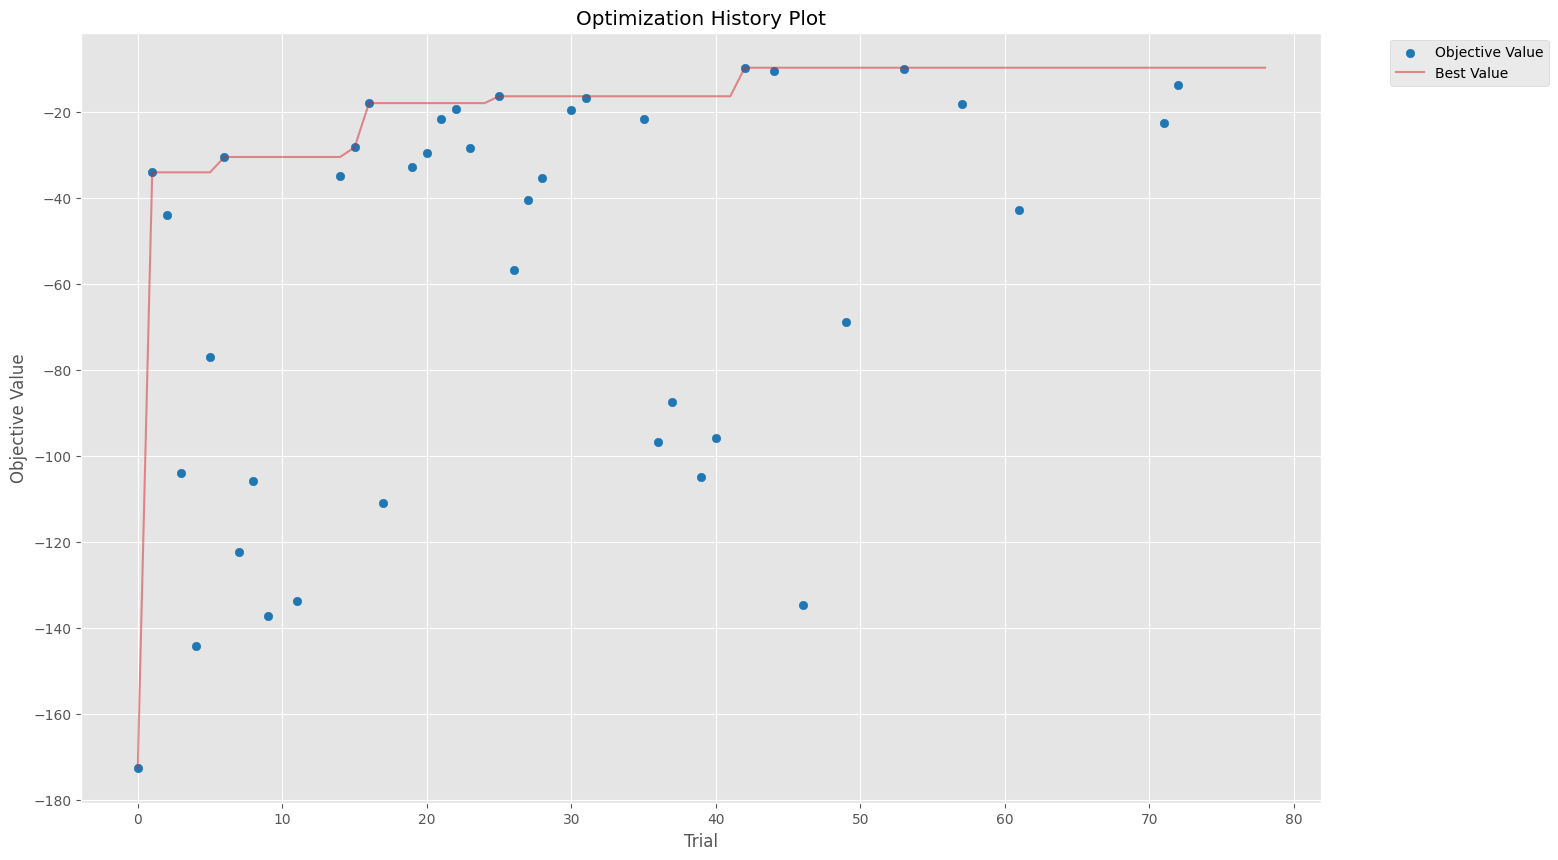

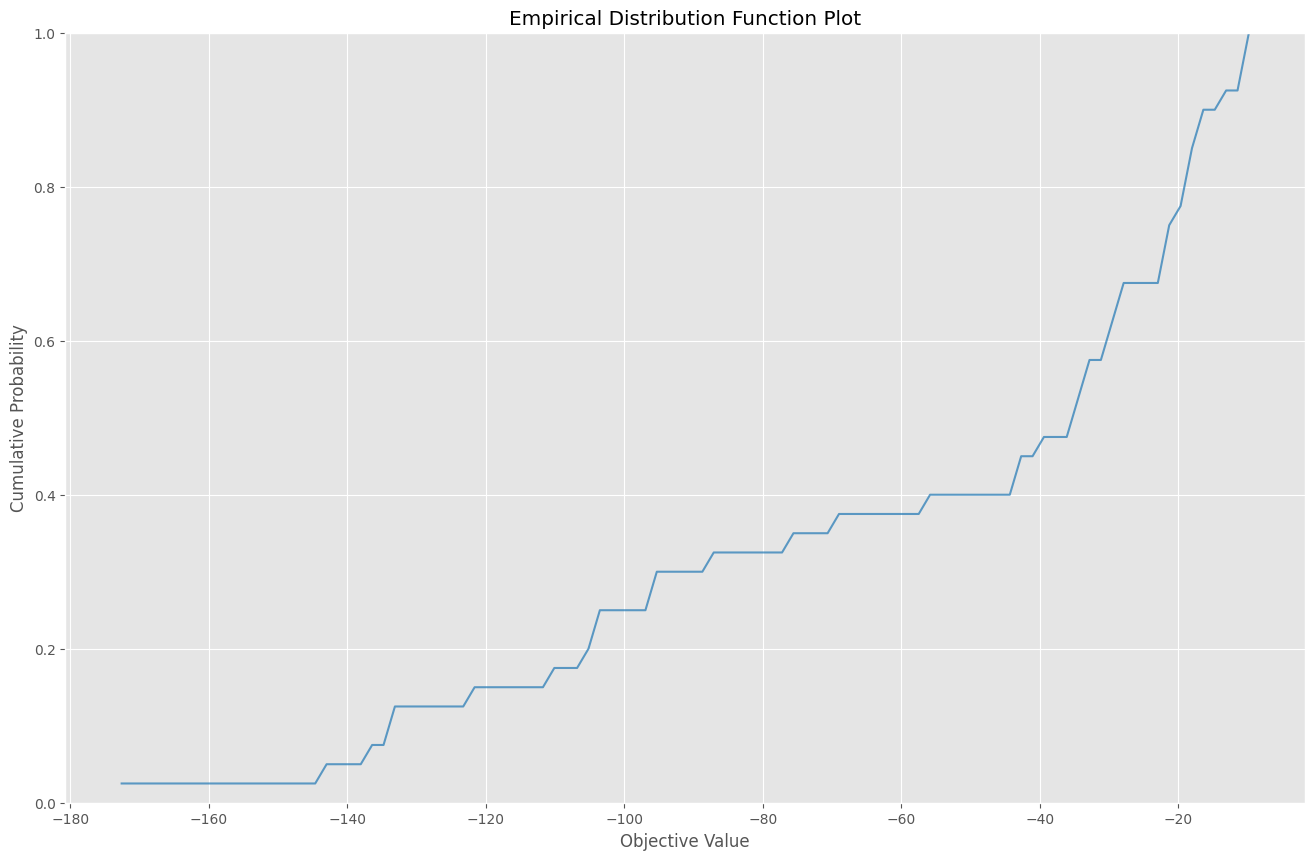

In [27]:
plot_optimization_history(sub_study);  # best value vs trial number
plot_edf(sub_study);    

In [1]:
# pip install wandb pandas numpy
import wandb, pandas as pd, numpy as np, re
from typing import Dict, Any

# --- EDIT THESE ---
ENTITY  = "jzapanag"
PROJECT = "TrafficSignalControl"
OBJECTIVE_KEY = "eval/weighted_avg"   # <-- change to the metric you care about
MODE = "max"                   # "max" or "min"
TOPK = 4

# Optional filters (uncomment/tweak as needed)
WB_FILTERS = {
    "state": "finished",        # only finished runs
    # "sweep": "xxxxxx",        # keep only a specific sweep
    # "tags": {"$in": ["hpo"]}, # runs that include a given tag
    #"config.study_name": "my_study",  # any config filter you used
}

api = wandb.Api(timeout=60)
runs = api.runs(f"{ENTITY}/{PROJECT}", filters=WB_FILTERS)

def family(summary, prefix):
    """Return {volume:int -> value:float} for keys like 'prefix@<vol>'."""
    out = {}
    pat = re.compile(rf"^{re.escape(prefix)}(\d+)$")
    for k, v in (summary or {}).items():
        if not isinstance(k, str): 
            continue
        m = pat.match(k)
        if m:
            vol = int(m.group(1))
            try:
                out[vol] = float(v)
            except (TypeError, ValueError):
                pass
    return out

def flat_simple_config(cfg: Dict[str, Any]) -> Dict[str, Any]:
    """Keep only simple scalar hyperparams (int/float/str/bool)."""
    keep = {}
    for k, v in (cfg or {}).items():
        if k.startswith("_"):   # ignore W&B internals
            continue
        if isinstance(v, (int, float, str, bool)) or v is None:
            keep[k] = v
    return keep

def collect_prefix(summary: Dict[str, Any], prefix: str) -> Dict[str, Any]:
    """Collect summary items that start with a given prefix (e.g., per-volume logs)."""
    return {k: summary[k] for k in summary if isinstance(k, str) and k.startswith(prefix)}

rows = []
for r in runs:
    summ = dict(r.summary or {})
    cfg  = flat_simple_config(dict(r.config or {}))
    obj  = summ.get(OBJECTIVE_KEY)

    if obj is None:
        continue  # skip runs without the objective

    # Example: aggregate per-volume metrics if you logged like "eval/score@1500"
    per_vol = collect_prefix(summ, "eval/score@")
    score_at_mean = np.nanmean(list(per_vol.values())) if per_vol else None

    speed   = family(summ, "eval/avg_speed@")
    qlen    = family(summ, "eval/avg_queue_length@")
    cwait   = family(summ, "eval/cumulative_wait@")
    scores  = family(summ, "eval/score@")

    rows.append({
        "name": r.name,
        "run_id": r.id,
        "url": f"https://wandb.ai/{ENTITY}/{PROJECT}/runs/{r.id}",
        OBJECTIVE_KEY: obj,
        "eval/score@mean": score_at_mean,
        # Add any other summary metrics you want to surface:
        "eval/avg_speed":         summ.get("eval/avg_speed"),
        "eval/cumulative_wait":   summ.get("eval/cumulative_wait"),
        "eval/avg_queue_length":  summ.get("eval/avg_queue_length"),
        "avg_speed_by_vol": speed,
        "avg_queue_length_by_vol": qlen,
        "cumulative_wait_by_vol": cwait, 
        "scores_by_vol": scores,})

df = pd.DataFrame(rows)
if df.empty:
    raise RuntimeError("No runs matched your filters or none had the chosen objective key.")

# Sort by objective and take top-K
ascending = (MODE.lower() == "min")
top = df.sort_values(OBJECTIVE_KEY, ascending=ascending).head(TOPK).reset_index(drop=True)

def expand_family(colname):
    # union of all volumes present in TOPK
    vols = sorted(set(v for d in top[colname] for v in (d or {}).keys()))
    for v in vols:
        top[f"{colname.replace('_by_vol','')}@{v}"] = top[colname].apply(lambda d: d.get(v) if isinstance(d, dict) else np.nan)

expand_family("avg_speed_by_vol")
expand_family("avg_queue_length_by_vol")
expand_family("cumulative_wait_by_vol")
expand_family("scores_by_vol")

# Final compact view
keep = ["name","run_id","url",OBJECTIVE_KEY]
# plus expanded per-volume columns if you want them visible:
keep += [c for c in top.columns if c.startswith("avg_speed@")]
keep += [c for c in top.columns if c.startswith("avg_queue_length@")]
keep += [c for c in top.columns if c.startswith("cumulative_wait@")]
keep += [c for c in top.columns if c.startswith("scores@")]

top[keep]


,name,run_id,url,eval/weighted_avg,avg_speed@1000,avg_speed@1100,avg_speed@1200,avg_speed@1300,avg_speed@1400,avg_speed@1500,...,scores@1100,scores@1200,scores@1300,scores@1400,scores@1500,scores@1600,scores@1700,scores@1800,scores@1900,scores@2000
0,trial-43-v6,v9swq2wn,https://wandb.ai/jzapanag/TrafficSignalControl...,-9.787475,6.790605,7.181442,6.965462,6.610837,6.680522,6.307953,...,-3.834842,-4.967773,-6.262504,-7.085248,-9.174112,-8.715061,-11.024825,-11.400885,-16.168151,-15.972459
1,trial-54-v6,qzhahst2,https://wandb.ai/jzapanag/TrafficSignalControl...,-9.986989,7.130476,7.510218,7.287120,6.962333,6.774176,6.459725,...,-3.821969,-4.968224,-6.158675,-7.056585,-8.592841,-9.339275,-11.861201,-12.196966,-15.536785,-16.878798
2,trial-45-v6,c63r9r6g,https://wandb.ai/jzapanag/TrafficSignalControl...,-10.505332,8.215135,8.890794,8.596786,8.466145,7.935627,7.814272,...,-1.707824,-2.362322,-2.888790,-4.206053,-5.734351,-9.281260,-15.026666,-12.341281,-20.397297,-23.716374
3,trial-74-v6,bds6hcdd,https://wandb.ai/jzapanag/TrafficSignalControl...,-13.842606,7.211471,7.978449,7.018747,6.669711,6.131029,5.791857,...,-2.863379,-4.518811,-5.889126,-7.461098,-10.621781,-11.406764,-19.086590,-20.126292,-21.516030,-27.661462


In [2]:
speeds = [c for c in top.columns if c.startswith("avg_speed@")]
queues = [c for c in top.columns if c.startswith("avg_queue_length@")]
waits = [c for c in top.columns if c.startswith("cumulative_wait@")]

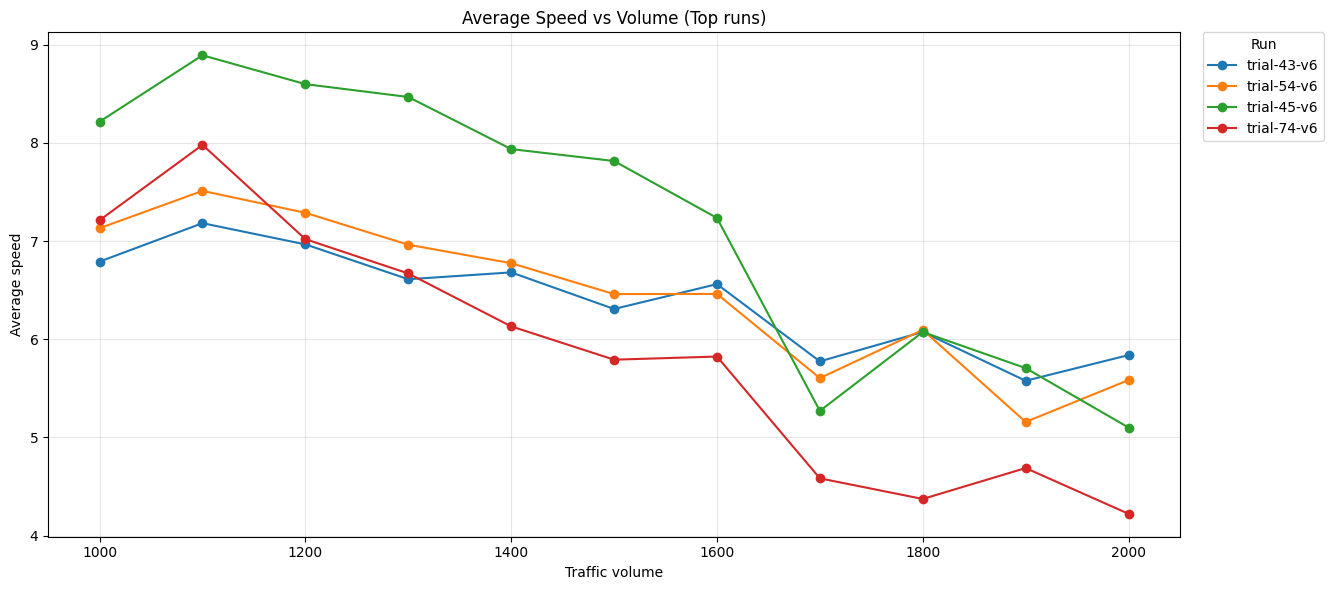

In [9]:
import re
import matplotlib.pyplot as plt

def _sorted_family_columns(df, prefix):
    """Return (volumes, columns) sorted by numeric volume extracted from 'prefix@<vol>'."""
    pat = re.compile(rf"^{re.escape(prefix)}(\d+)$")
    pairs = []
    for c in df.columns:
        m = pat.match(c)
        if m:
            pairs.append((int(m.group(1)), c))
    pairs.sort(key=lambda x: x[0])
    vols = [v for v, _ in pairs]
    cols = [c for _, c in pairs]
    return vols, cols

def plot_family_lines(top_df, prefix, title, ylabel):
    vols, cols = _sorted_family_columns(top_df, prefix)
    if not cols:
        print(f"No columns found for prefix '{prefix}'.")
        return

    plt.figure(figsize=(12, 6))
    # one line per run
    for _, row in top_df.iterrows():
        y = row[cols].values.astype(float)
        plt.plot(vols, y, marker="o", label=str(row["name"]))

    plt.title(title)
    plt.xlabel("Traffic volume")
    plt.ylabel(ylabel)
    plt.grid(True, axis="both", alpha=0.3)

    # Legend outside on the right
    ax = plt.gca()
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.80, box.height])
    plt.legend(title="Run", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

    plt.tight_layout()
    plt.show()

# === Call for each metric family ===
plot_family_lines(top, prefix="avg_speed@",           title="Average Speed vs Volume (Top runs)",        ylabel="Average speed")

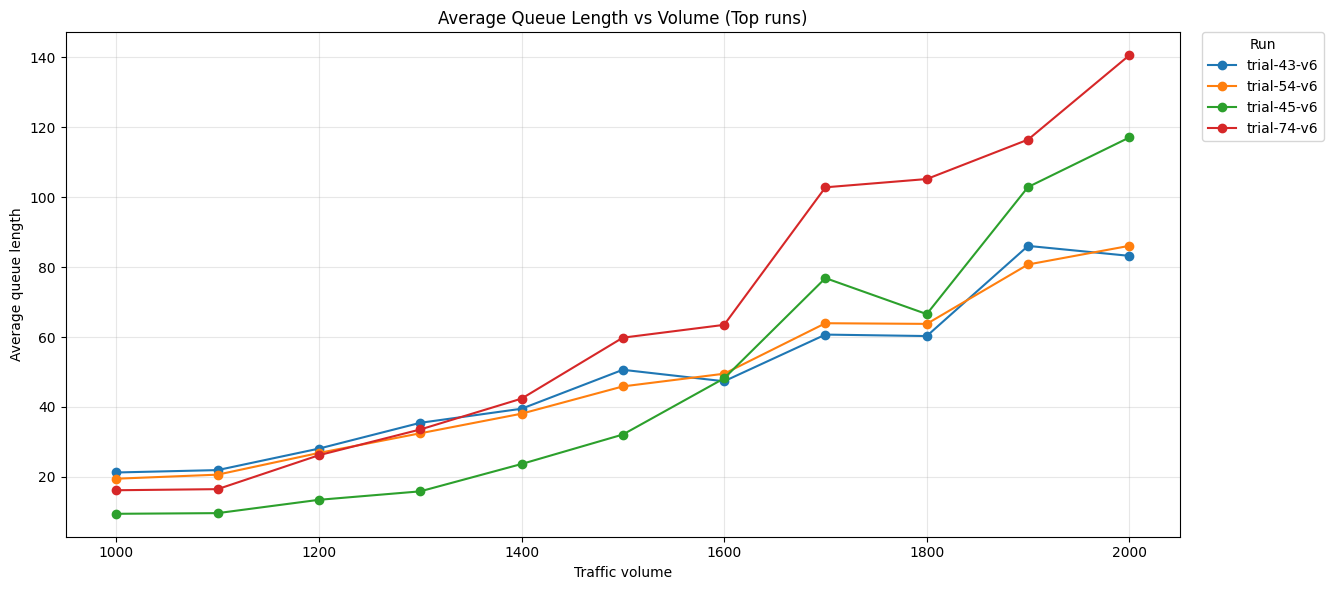

In [8]:
plot_family_lines(top, prefix="avg_queue_length@",    title="Average Queue Length vs Volume (Top runs)", ylabel="Average queue length")

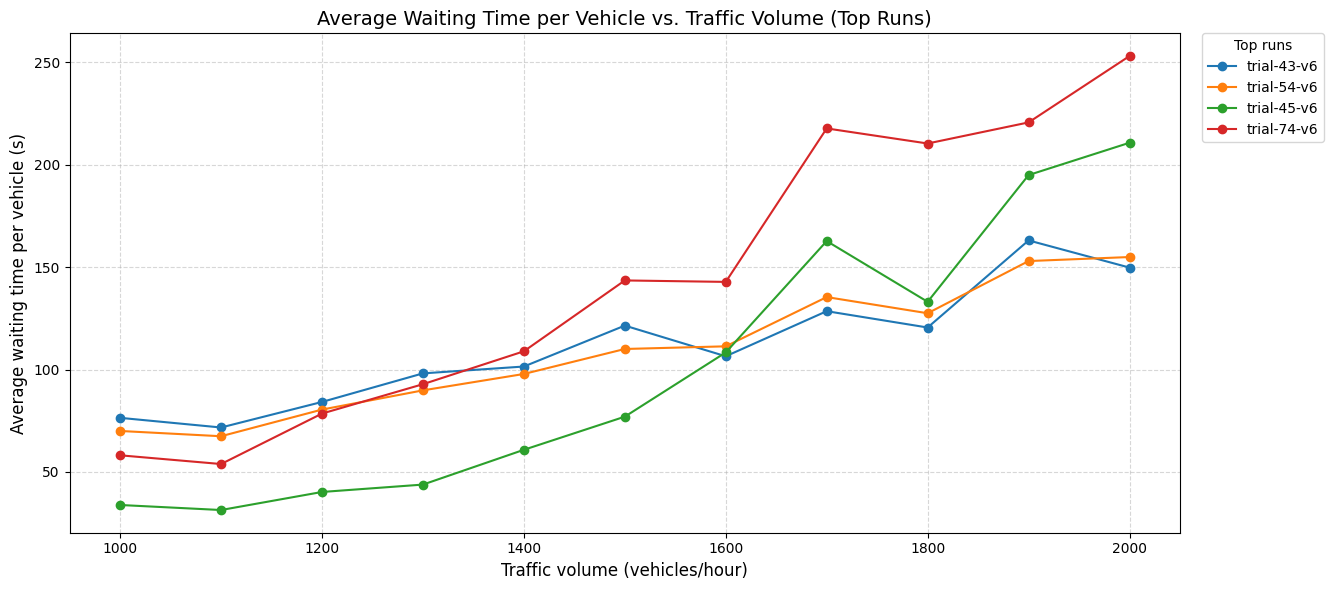

In [5]:
def _sorted_family_columns(df, prefix):
    pat = re.compile(rf"^{re.escape(prefix)}(\d+)$")
    pairs = []
    for c in df.columns:
        m = pat.match(c)
        if m:
            pairs.append((int(m.group(1)), c))
    pairs.sort(key=lambda x: x[0])
    vols = [v for v, _ in pairs]
    cols = [c for _, c in pairs]
    return vols, cols

def plot_avg_wait(top_df, prefix="cumulative_wait@", title=None):
    vols, cols = _sorted_family_columns(top_df, prefix)
    if not cols:
        print(f"No columns found for prefix '{prefix}'.")
        return

    plt.figure(figsize=(12, 6))
    for _, row in top_df.iterrows():
        y = row[cols].values.astype(float)
        # convert to average wait per vehicle
        y_avg = y / np.array(vols, dtype=float)
        plt.plot(vols, y_avg, marker="o", label=str(row["name"]))

    plt.title(title or "Average Waiting Time per Vehicle vs. Traffic Volume", fontsize=14)
    plt.xlabel("Traffic volume (vehicles/hour)", fontsize=12)
    plt.ylabel("Average waiting time per vehicle (s)", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.5)

    ax = plt.gca()
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    plt.legend(title="Top runs", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout()
    plt.show()

# === call the function ===
plot_avg_wait(
    top,
    prefix="cumulative_wait@",
    title="Average Waiting Time per Vehicle vs. Traffic Volume (Top Runs)"
)

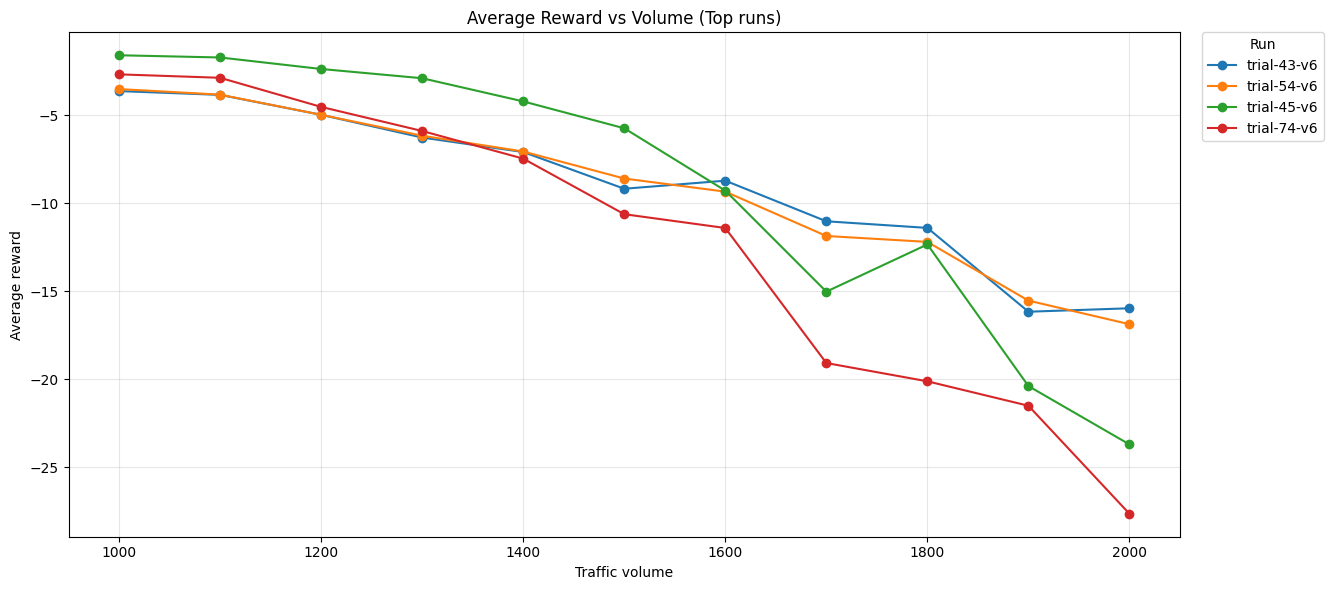

In [6]:
plot_family_lines(top, prefix="scores@",     title="Average Reward vs Volume (Top runs)",      ylabel="Average reward")

In [7]:
run_ids = top["run_id"].tolist()
records = []
for rid in run_ids:
    run = api.run(f"{ENTITY}/{PROJECT}/{rid}")
    cfg = dict(run.config or {})
    search_space = cfg.get("search_space", {})
    records.append({"run_name": run.name, **search_space})

top_hparams = pd.DataFrame(records)
top_hparams

,run_name,gamma,lambd,l2_reg,strides,K_epochs,clip_rate,optimizer,lstm_units,num_filters,num_neurons,entropy_coef,kernels_size,weight_decay,learning_rate,num_mlp_layers,num_conv_layers
0,trial-43-v6,0.980,0.98,1.767795e-10,[2],7,0.18,adam,128,[128],[64],0.015712,[3],0.000000,0.000198,2,1
1,trial-54-v6,0.981,0.98,9.843353e-07,[3],7,0.12,adam,256,[128],[64],0.015238,[5],0.000000,0.000822,2,1
2,trial-45-v6,0.980,0.97,9.852437e-12,[1],8,0.15,adamw,128,[64],[64],0.018624,[3],0.000009,0.000279,2,1
3,trial-74-v6,0.980,0.96,1.221667e-12,[1],6,0.16,adamw,96,[32],[64],0.014882,[3],0.000008,0.000225,2,1
